# I Gaussian Process Regression

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

We define a function `man_ExpSquaredKernel(t, A=1.0, l=1.0)` that returns the covariance matrix described by the squared exponential kernel for two arrays of times `t1` and `t2`. (We can also use it as `from george.kernels import ExpSquaredKernel`, where, the *metric* parameter in `ExpSquaredKernel` represents $2.l^2$ (where $l$ is the length scale))

> Mathematically, the `Squared-Exponential Kernel` or (Gaussian Kernel) can be written as: <br>
<p style="text-align:center">$ k(t, t') =  \sigma^2 \exp \left( - \frac{(t - t')^2}{2l^2} \right)$</p> <br>

where, <br>
* $\sigma^2 = A$  is the signal variance
* `l` is the lengthscale

In [2]:
def man_ExpSquaredKernel(t1, t2=None, A=1.0, l=1.0):
    if t2 is None:
        t2 = t1
    T2, T1 = np.meshgrid(t2, t1)
    return A ** 2 * np.exp(-0.5 * (T1-T2)**2 / l**2)

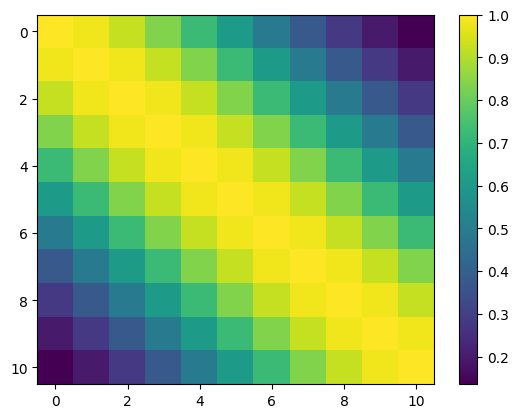

In [3]:
# Visual representation of the Kernel Matrix
t = np.linspace(0,2,11)
S = man_ExpSquaredKernel(t)
plt.imshow(S, interpolation='nearest',aspect='auto')
plt.colorbar();

To draw samples from a multivariate Gaussian given its mean vector `mu` and its covariance matrix `S`, we can use `np.random.multivariate_normal`.

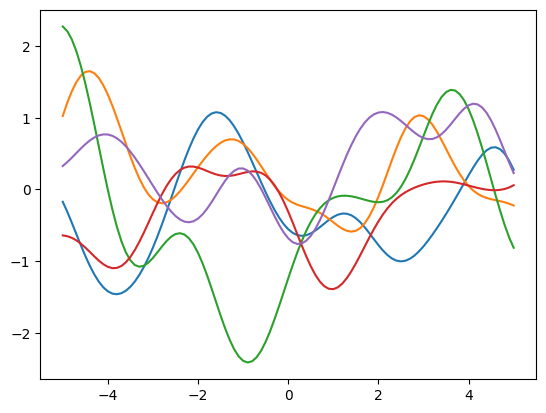

In [4]:
np.random.seed(42)

t = np.linspace(-5,5,101)
mu = np.zeros_like(t)
S = man_ExpSquaredKernel(t)
samples = np.random.multivariate_normal(mu, S, 5)
plt.plot(t,samples.T);

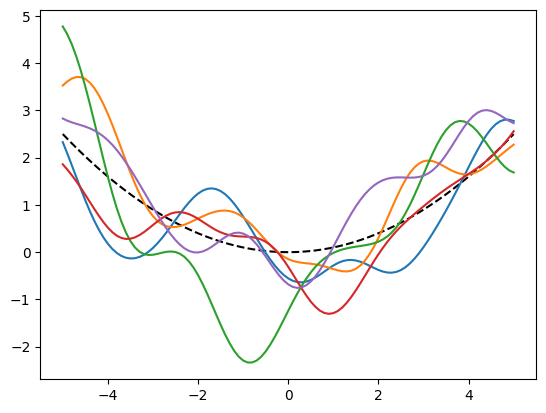

In [5]:
np.random.seed(42)

# Introduced a non-trivial mean vector
mu = 0.1 * t**2
plt.plot(t,mu,'k--')
samples = np.random.multivariate_normal(mu, S, 5)
plt.plot(t,samples.T);

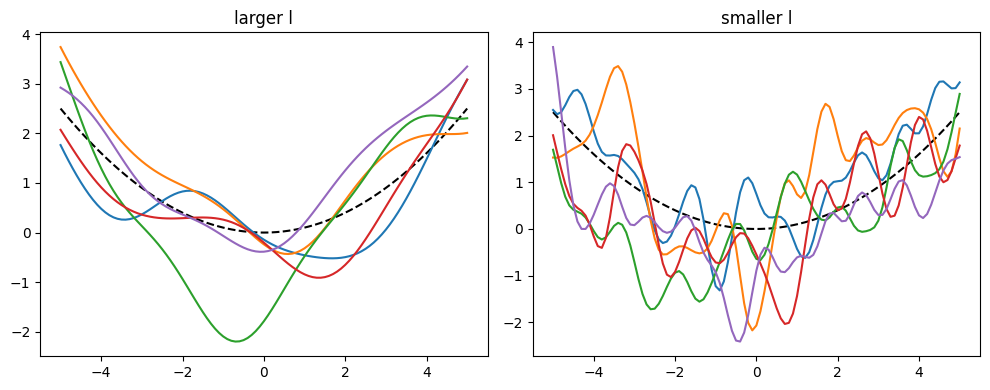

In [6]:
np.random.seed(42)

mu = 0.1 * t**2
S1 = man_ExpSquaredKernel(t, l = 1.6)
S2 = man_ExpSquaredKernel(t, l = 0.4)
samples1 = np.random.multivariate_normal(mu, S1, 5)
samples2 = np.random.multivariate_normal(mu, S2, 5)

fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(10, 4))

plot1.plot(t, mu, 'k--')
plot1.plot(t, samples1.T)
plot1.set_title("larger l")

plot2.plot(t, mu, 'k--')
plot2.plot(t, samples2.T)
plot2.set_title("smaller l")

plt.tight_layout()
plt.show()

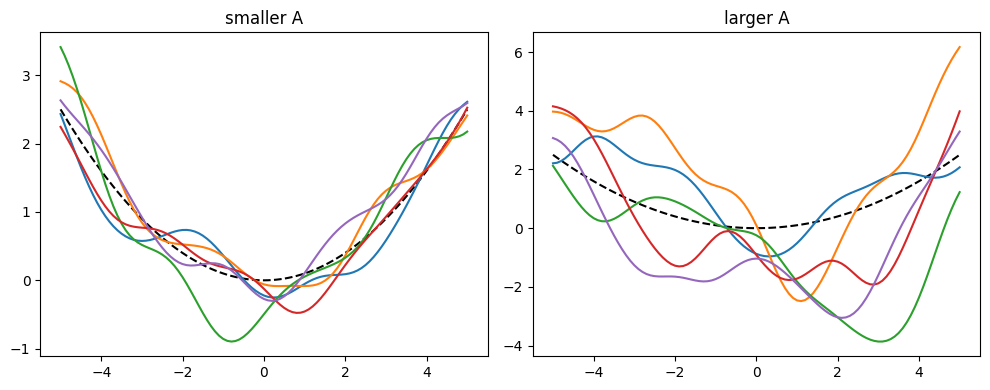

In [7]:
np.random.seed(42)

mu = 0.1 * t**2
S3 = man_ExpSquaredKernel(t, A = 0.4)
S4 = man_ExpSquaredKernel(t, A = 1.6)
samples3 = np.random.multivariate_normal(mu, S3, 5)
samples4 = np.random.multivariate_normal(mu, S4, 5)

fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(10, 4))

plot1.plot(t, mu, 'k--')
plot1.plot(t, samples3.T)
plot1.set_title("smaller A")

plot2.plot(t, mu, 'k--')
plot2.plot(t, samples4.T)
plot2.set_title("larger A")

plt.tight_layout()
plt.show()

### Conditioning GP on some prior data

We showcase this on an exemplar `t_train` data randomly generated

Next, we define a function `compute_gp` that evaluates the mean vector `mu` and covariance matrix `S` of the GP evaluated at training points `t_test` given some data (`t_train`, `y_train`).

In [8]:
def compute_gp(t_train, y_train, t_test, kernel = man_ExpSquaredKernel, **kwargs):
    # Compute the required matrices
    Stt = kernel(t_train, **kwargs)
    Spp = kernel(t_test, **kwargs)
    Spt = kernel(t_test, t_train, **kwargs)

    # Compute the mean and covariance of the GP
    mu = np.dot(Spt, np.linalg.solve(Stt, y_train))
    S = Spp - np.dot(Spt, np.linalg.solve(Stt, Spt.T))

    return mu, S

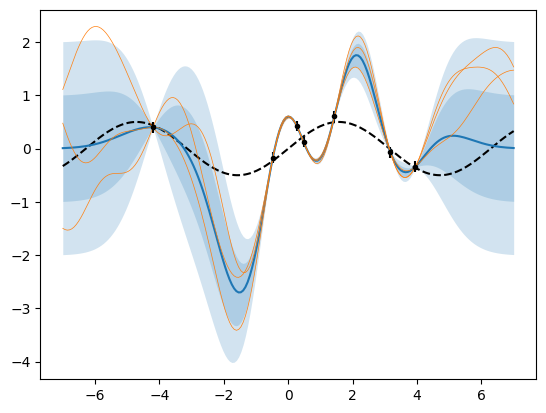

In [9]:
t_train = np.random.uniform(-5,5,7) # len =7
wn = 0.1
y_train = 0.5 * np.sin(t_train) + np.random.normal(0, 1, len(t_train)) * wn
plt.errorbar(t_train, y_train, yerr = wn, fmt='k.', capsize=0)
t_test = np.linspace(-7, 7, 201)
y_true = 0.5 * np.sin(t_test)
plt.plot(t_test, y_true, 'k--')
gp_mu, gp_S = compute_gp(t_train, y_train, t_test)
sig = np.sqrt(gp_S.diagonal())
plt.plot(t_test, gp_mu, color="C0")
plt.fill_between(t_test, gp_mu - sig, gp_mu + sig, color="C0", alpha=0.2,lw=0);
plt.fill_between(t_test, gp_mu - 2 * sig, gp_mu + 2 * sig, color="C0", alpha=0.2,lw=0);
samples = np.random.multivariate_normal(gp_mu, gp_S,3)
plt.plot(t_test, samples.T, color="C1", lw=0.5);

Next, we define the negative log likelihood (`nll`) function of the GP

In [10]:
def nll_gp(p, t, y, sigma):
    A, l = np.exp(p)
    npts = len(t)
    K = man_ExpSquaredKernel(t, A = A, l=l) + sigma ** 2 * np.eye(npts)
    nll = 0.5 * np.dot(y.T, np.linalg.solve(K, y))
    nll += 0.5 * np.linalg.slogdet(K)[1]
    nll += 0.5 * npts * np.log(2 * np.pi)
    return nll

[1. 1.] 7.447392517385281
[0.38806854 1.33050833] 4.27645336794926


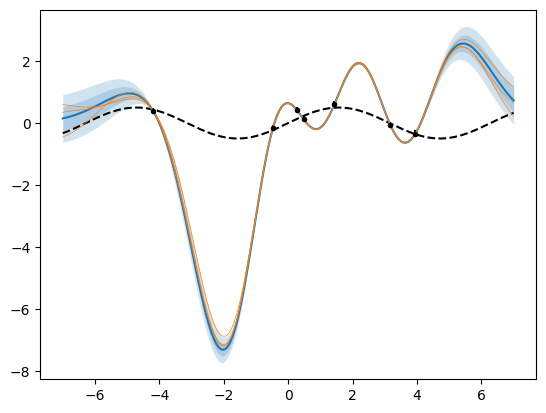

In [11]:
from scipy.optimize import minimize 
p0 = np.array([0.0, 0.0])

print(np.exp(p0),nll_gp(p0,t_train,y_train,wn))
res = minimize(nll_gp, p0, args = (t_train, y_train, wn))
ml_par = res.x
print(np.exp(ml_par), res.fun)

plt.errorbar(t_train, y_train, yerr = wn, fmt='k.', capsize=0)
plt.plot(t_test, y_true, 'k--')
gp_mu, gp_S = compute_gp(t_train, y_train, t_test, A = np.exp(ml_par[0]), l = np.exp(ml_par[1]))
sig = np.sqrt(gp_S.diagonal())
plt.plot(t_test, gp_mu, color="C0")
plt.fill_between(t_test, gp_mu - sig, gp_mu + sig, color="C0", alpha=0.2,lw=0);
plt.fill_between(t_test, gp_mu - 2 * sig, gp_mu + 2 * sig, color="C0", alpha=0.2,lw=0);
samples = np.random.multivariate_normal(gp_mu, gp_S,3)
plt.plot(t_test, samples.T, color="C1", lw=0.5);

# II Simulating a noisy light curve with Sinusoidal and Gaussian waves

In [12]:
# Imports and seed
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Exponentiated Squared (RBF) Kernel
def ExpSquaredKernel(t1, t2=None, A=1.0, l=1.0):
    if t2 is None:
        t2 = t1
    T2, T1 = np.meshgrid(t2, t1)
    return A**2 * np.exp(-0.5 * (T1 - T2)**2 / l**2)

## Simulating a Sinusoidal Signal (e.g., stellar pulsation)

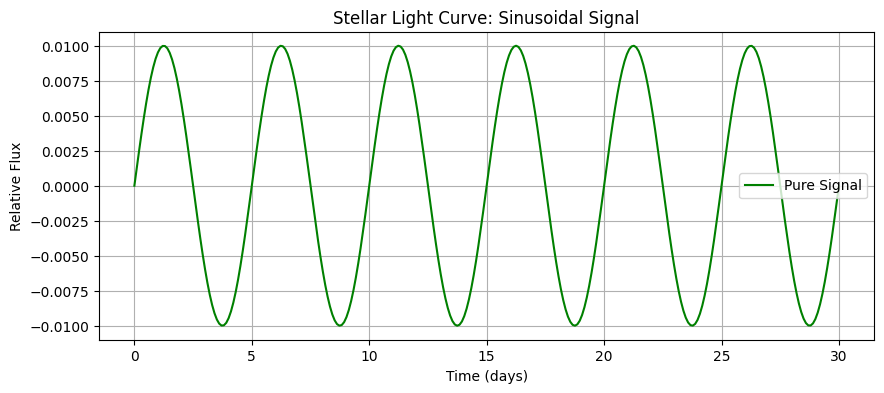

In [13]:
# Time array (e.g., 30 days sampled every 0.1 days)
t = np.linspace(0, 30, 300)

period = 5  # days
amplitude = 0.01  # relative flux
signal = amplitude * np.sin(2 * np.pi * t / period)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label="Pure Signal", color='green')
plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.title("Stellar Light Curve: Sinusoidal Signal")
plt.legend()
plt.grid(True)
plt.show()


## Simulating a GP Noise

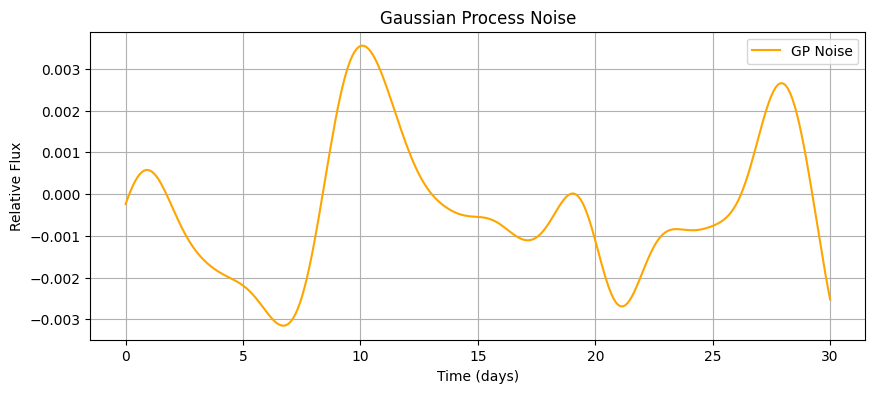

In [14]:
# Parameters: amplitude A and length scale l of the GP kernel
A_gp = 0.002  # smaller than signal amplitude
l_gp = 1.5    # correlation length scale

# Covariance matrix
cov = ExpSquaredKernel(t, A=A_gp, l=l_gp)

# Sample from the multivariate normal
noise = np.random.multivariate_normal(mean=np.zeros(len(t)), cov=cov)

plt.figure(figsize=(10, 4))
plt.plot(t, noise, label="GP Noise", color='orange')
plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.title("Gaussian Process Noise")
plt.legend()
plt.grid(True)
plt.show()

## Combining the two curves to simulate a Noisy Stellar Light Curve

We also add a `white_noise` to further simulate real signal capture. Here, the White Noise follows a Normal Distribution with variance $\sigma ^2$. Mathematically speaking,
`white_noise` ~ $N(0, \sigma ^2)$

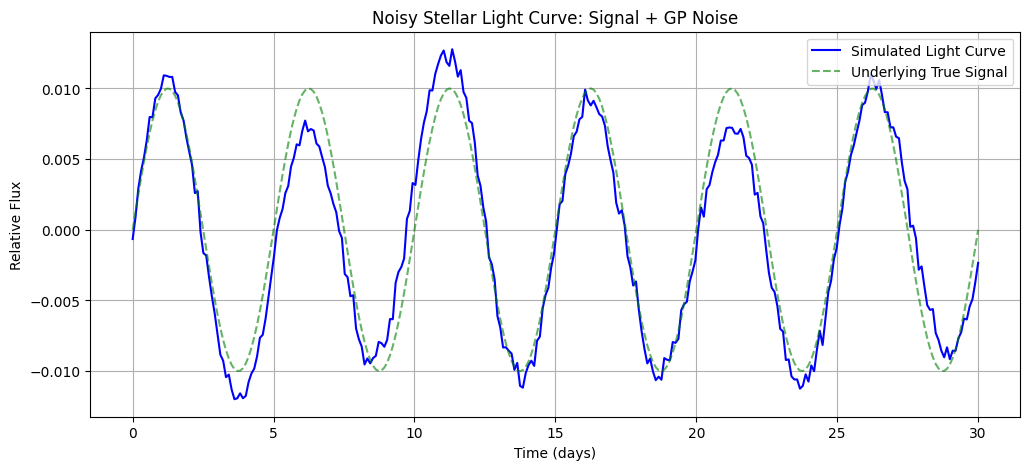

In [15]:
sigma = 0.0005
white_noise = np.random.normal(0, sigma, size=t.shape)

lightcurve = signal + noise + white_noise

plt.figure(figsize=(12, 5))
plt.plot(t, lightcurve, label="Simulated Light Curve", color='blue')
plt.plot(t, signal, label="Underlying True Signal", color='green', alpha=0.6, linestyle='--')
plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.title("Noisy Stellar Light Curve: Signal + GP Noise")
plt.legend()
plt.grid(True)
plt.show()


# III Stellar light curves from the Keplar Mission

The Kepler mission measured the brightnesses in the visible band of ∼150,000 stars every 29.4 minutes for nearly 4 years with very high precision. The mission successfully detected several thousand cases where an exoplanet transited across the stellar disk, causing faint periodic dips. But the effort was complicated by the wide range in intrinsic stellar variability. We illustrate some time series methods for evenly spaced time series using two stars that have been preprocessed using the procedures of Caceres et al. (2019). One star exhibits low level stochastic scatter characteristics of solar-type stars with low magnetic activity, and the other shows high levels of quasi-periodic variability from rotationally modulated starspots. We do not attempt to detect transiting exoplanets in this tutorial.

The **first** Kepler lightcurve `KIC 007596240`. The input data here is a vector of 71,427 evenly spaced flux measurements of which 16% are missing (NAs). The median is close to zero and the interquartile range is 6.5 flux units.<br>
The **second** Kepler lightcurve `(KIC 007609553)` shows high amplitude variability that is attributed to stellar rotation where the starlight is modulated as dark starspots rotate in and out of view. In simple words,<br>
`Kepler1.dat` → *quiet star* data <br>
`Kepler2.dat` → *rotation star* data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data (handle NA safely) and save memory using float32
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Count missing values
n_missing_flux1 = np.isnan(flux1).sum()
n_missing_flux2 = np.isnan(flux2).sum()
n_total_flux1 = len(flux1)
n_total_flux2 = len(flux2)
print(f"Kepler1: {n_missing_flux1}/{n_total_flux1} ({100 * n_missing_flux1 / n_total_flux1:.2f}% missing)")
print(f"kepler2: {n_missing_flux2}/{n_total_flux2} ({100 * n_missing_flux2 / n_total_flux2:.2f}% missing)")

Kepler1: 11337/71427 (15.87% missing)
kepler2: 20598/71427 (28.84% missing)


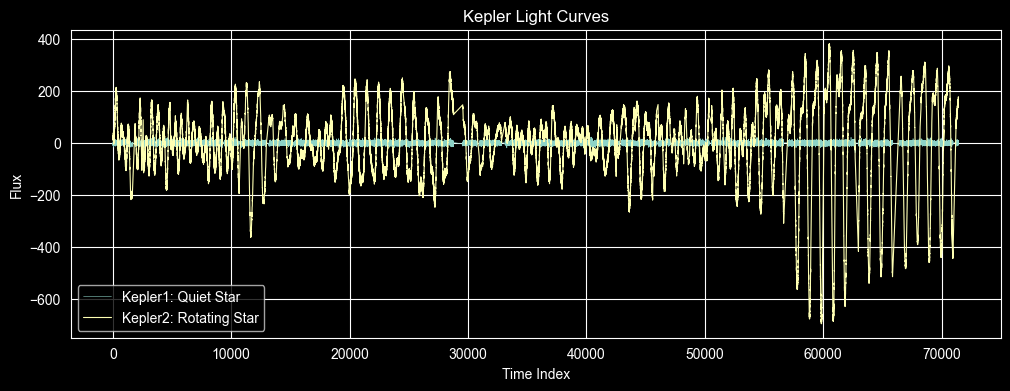

In [2]:
# Masked plots to ignore NaNs
t1 = np.arange(len(flux1))
t2 = np.arange(len(flux2))

plt.figure(figsize=(12, 4))
plt.plot(t1[~np.isnan(flux1)], flux1[~np.isnan(flux1)], lw=0.4, label='Kepler1: Quiet Star')
plt.plot(t2[~np.isnan(flux2)], flux2[~np.isnan(flux2)], lw=0.8, label='Kepler2: Rotating Star')
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Kepler Light Curves")
plt.grid(True)
plt.show()

In [18]:
from scipy.interpolate import interp1d

# Only use valid indices
valid1 = ~np.isnan(flux1)
interp_func1 = interp1d(t1[valid1], flux1[valid1], kind='linear', fill_value="extrapolate")
flux1_interp = interp_func1(t1)

valid2 = ~np.isnan(flux2)
interp_func2 = interp1d(t2[valid2], flux2[valid2], kind = 'linear', fill_value = 'extrapolate')
flux2_interp = interp_func2(t2)

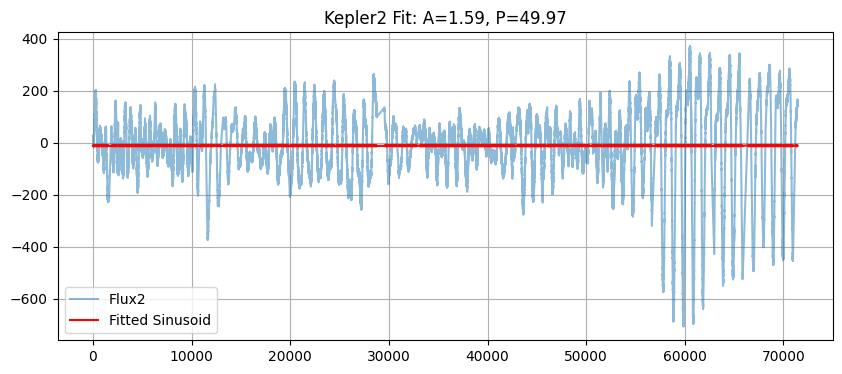

In [19]:
from scipy.optimize import curve_fit

def sinusoid(t, A, P, phi, offset):
    return A * np.sin(2 * np.pi * t / P + phi) + offset

# Use only finite values
finite = ~np.isnan(flux2)
t_fit = t2[finite]
f_fit = flux2[finite] - np.nanmedian(flux2)

# Initial guesses: A=10, P=50, phi=0, offset=0
popt, _ = curve_fit(sinusoid, t_fit, f_fit, p0=[10, 50, 0, 0])
A, P, phi, offset = popt

# Reconstruct fitted signal
fitted = sinusoid(t_fit, *popt)

plt.figure(figsize=(10, 4))
plt.plot(t_fit, f_fit, label='Flux2', alpha=0.5)
plt.plot(t_fit, fitted, label='Fitted Sinusoid', color='r')
plt.legend()
plt.title(f"Kepler2 Fit: A={A:.2f}, P={P:.2f}")
plt.grid(True)
plt.show()

## Using Gaussian Processes to simulate probable noise

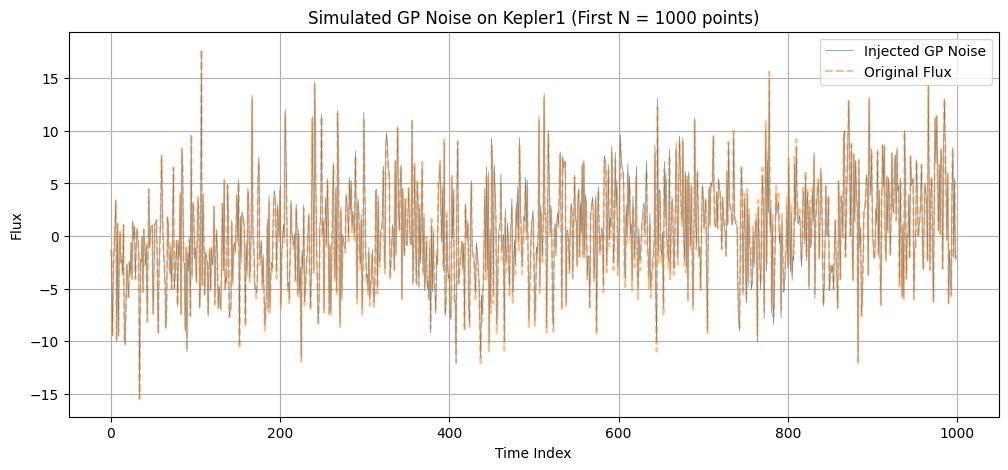

In [20]:
np.random.seed(442)

def man_ExpSquaredKernel(t1, t2=None, A=1.0, l=1.0):
    if t2 is None:
        t2 = t1
    T2, T1 = np.meshgrid(t2, t1)
    return A ** 2 * np.exp(-0.5 * (T1-T2)**2 / l**2)

N = 1000
t1_sub = t1[:N]
flux1_sub = flux1_interp[:N]

cov1_sub = man_ExpSquaredKernel(t1_sub, A = 0.5, l = 50.0)
gp_noise_sub1 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov1_sub)

# Add GP noise
flux_gp_injected1 = flux1_sub + gp_noise_sub1

plt.figure(figsize=(12, 5))
plt.plot(t1_sub, flux_gp_injected1, label='Injected GP Noise', lw = 0.4)
plt.plot(t1_sub, flux1_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler1 (First N = 1000 points)")
plt.grid(True)
plt.show()

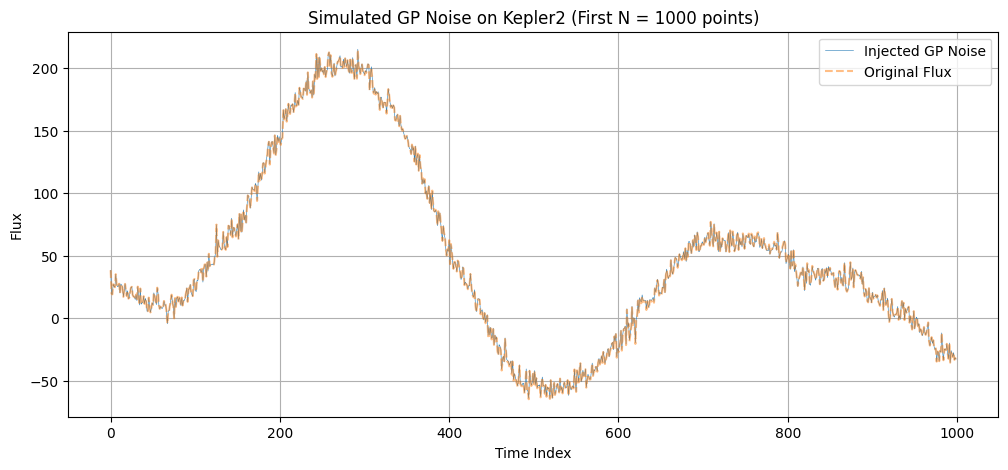

In [21]:
np.random.seed(442)

N = 1000
t2_sub = t2[:N]
flux2_sub = flux2_interp[:N]

cov2_sub = man_ExpSquaredKernel(t2_sub, A = 0.5, l = 50.0)
gp_noise_sub2 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov2_sub)

# Add GP noise
flux_gp_injected2 = flux2_sub + gp_noise_sub2

plt.figure(figsize=(12, 5))
plt.plot(t2_sub, flux_gp_injected2, label='Injected GP Noise', lw = 0.4)
plt.plot(t2_sub, flux2_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler2 (First N = 1000 points)")
plt.grid(True)
plt.show()

## Using GPR to model around Kepler datas

### Imputing missing values in `Kepler1.dat`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.interpolate import interp1d
import IPython.display as display

# Step 1: Load flux data (Note: ensure path matches your environment)
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Step 2: Create time index
t1 = np.arange(len(flux1))

# Step 3: Get observed (non-NaN) values ONLY
mask = ~np.isnan(flux1)
t1_valid = t1[mask]
y1_valid = flux1[mask]

# Step 3.5: Subsample the flux data before split to manage O(N^3) memory constraints
subset = 100
t1_sub = t1_valid[::subset]
y1_sub = y1_valid[::subset]

# Step 3.6: Randomized Train-Test Split (80% Train, 20% Test)

# --- 1. Setup Monte Carlo Cross-Validation ---
n_repetitions = 20
seeds = range(n_repetitions)

# Storage for GP metrics
gp_rmse_list, gp_mae_list, gp_r2_list = [], [], []
gp_1sigma_list, gp_2sigma_list, gp_std_list = [], [], []

# Storage for Baseline metrics
lin_rmse_list, lin_mae_list, lin_r2_list = [], [], []
cub_rmse_list, cub_mae_list, cub_r2_list = [], [], []

print(f"Running Monte Carlo Cross-Validation across {n_repetitions} seeds...")

kernel1 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)

for seed in seeds:
    # Randomized Split
    t1_train, t1_test, y1_train, y1_test = train_test_split(
        t1_sub, y1_sub, test_size=0.2, random_state=seed
    )

    # Sort arrays for clean interpolation
    sort_train = np.argsort(t1_train)
    t1_train, y1_train = t1_train[sort_train], y1_train[sort_train]
    sort_test = np.argsort(t1_test)
    t1_test, y1_test = t1_test[sort_test], y1_test[sort_test]

    X1_train, X1_test = t1_train.reshape(-1, 1), t1_test.reshape(-1, 1)

    # --- Fit & Evaluate GP ---
    gpr1 = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr1.fit(X1_train, y1_train)
    y1_pred, y1_std = gpr1.predict(X1_test, return_std=True)

    gp_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y1_pred)))
    gp_mae_list.append(mean_absolute_error(y1_test, y1_pred))
    gp_r2_list.append(r2_score(y1_test, y1_pred))
    gp_std_list.append(np.mean(y1_std))

    # Uncertainty Coverage
    gp_1sigma_list.append(np.mean((y1_test >= y1_pred - y1_std) & (y1_test <= y1_pred + y1_std)))
    gp_2sigma_list.append(np.mean((y1_test >= y1_pred - 2*y1_std) & (y1_test <= y1_pred + 2*y1_std)))

    # --- Fit & Evaluate Baselines ---
    # Linear
    lin_interp = interp1d(t1_train, y1_train, kind='linear', fill_value='extrapolate')
    y_pred_lin = lin_interp(t1_test)
    lin_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_lin)))
    lin_mae_list.append(mean_absolute_error(y1_test, y_pred_lin))
    lin_r2_list.append(r2_score(y1_test, y_pred_lin))

    # Cubic
    cub_interp = interp1d(t1_train, y1_train, kind='cubic', fill_value='extrapolate')
    y_pred_cub = cub_interp(t1_test)
    cub_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_cub)))
    cub_mae_list.append(mean_absolute_error(y1_test, y_pred_cub))
    cub_r2_list.append(r2_score(y1_test, y_pred_cub))

print("Monte Carlo evaluation complete.")

Running Monte Carlo Cross-Validation across 20 seeds...
Monte Carlo evaluation complete.


In [4]:
# --- 1. Compute Aggregates ---
benchmark_data = {
    "Method": ["Linear Interpolation", "Cubic Spline", "Gaussian Process"],
    "RMSE Mean": [np.mean(lin_rmse_list), np.mean(cub_rmse_list), np.mean(gp_rmse_list)],
    "RMSE Std": [np.std(lin_rmse_list), np.std(cub_rmse_list), np.std(gp_rmse_list)],
    "MAE Mean": [np.mean(lin_mae_list), np.mean(cub_mae_list), np.mean(gp_mae_list)],
    "MAE Std": [np.std(lin_mae_list), np.std(cub_mae_list), np.std(gp_mae_list)],
    "R² Mean": [np.mean(lin_r2_list), np.mean(cub_r2_list), np.mean(gp_r2_list)],
    "R² Std": [np.std(lin_r2_list), np.std(cub_r2_list), np.std(gp_r2_list)]
}

benchmark_df = pd.DataFrame(benchmark_data)

print("--- Kepler 1 Benchmark Results (20 Seeds) ---")
display.display(benchmark_df.round(4))

# --- 2. Uncertainty Calibration Summary ---
print("\n--- GP Uncertainty Calibration Summary ---")
print(f"Average 1σ Coverage: {np.mean(gp_1sigma_list)*100:.2f}% ± {np.std(gp_1sigma_list)*100:.2f}% (Ideal: ~68%)")
print(f"Average 2σ Coverage: {np.mean(gp_2sigma_list)*100:.2f}% ± {np.std(gp_2sigma_list)*100:.2f}% (Ideal: ~95%)")

# --- 3. Best/Worst Case Analysis ---
best_seed_idx = np.argmin(gp_rmse_list)
worst_seed_idx = np.argmax(gp_rmse_list)
print("\n--- Sensitivity to Train-Test Split ---")
print(f"Best GP RMSE:  {gp_rmse_list[best_seed_idx]:.4f} (Seed {seeds[best_seed_idx]})")
print(f"Worst GP RMSE: {gp_rmse_list[worst_seed_idx]:.4f} (Seed {seeds[worst_seed_idx]})")

--- Kepler 1 Benchmark Results (20 Seeds) ---


,Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R² Mean,R² Std
0,Linear Interpolation,6.2827,0.3437,5.1008,0.3127,-0.5733,0.1151
1,Cubic Spline,8.6941,1.1385,6.6883,0.5017,-2.0335,0.7128
2,Gaussian Process,5.0477,0.2525,4.1156,0.2176,-0.0136,0.0182



--- GP Uncertainty Calibration Summary ---
Average 1σ Coverage: 65.12% ± 4.24% (Ideal: ~68%)
Average 2σ Coverage: 96.07% ± 1.63% (Ideal: ~95%)

--- Sensitivity to Train-Test Split ---
Best GP RMSE:  4.6718 (Seed 11)
Worst GP RMSE: 5.5869 (Seed 7)


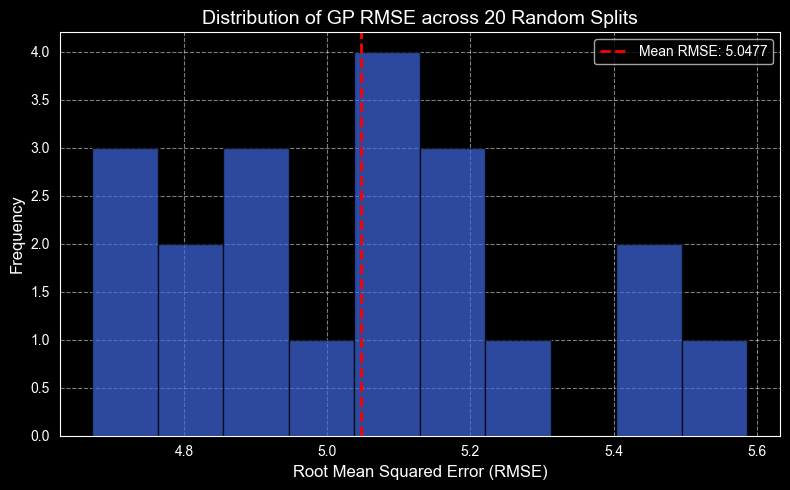

In [5]:
# --- Plot RMSE Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(gp_rmse_list, bins=10, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(gp_rmse_list), color='red', linestyle='dashed', linewidth=2, label=f'Mean RMSE: {np.mean(gp_rmse_list):.4f}')
plt.title(f"Distribution of GP RMSE across {n_repetitions} Random Splits", fontsize=14)
plt.xlabel("Root Mean Squared Error (RMSE)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### --- Visualization of the Best GP Model Split for Kepler 1 ---


Generating visualization for Best Kepler 1 Seed: 11 (RMSE: 4.6718)


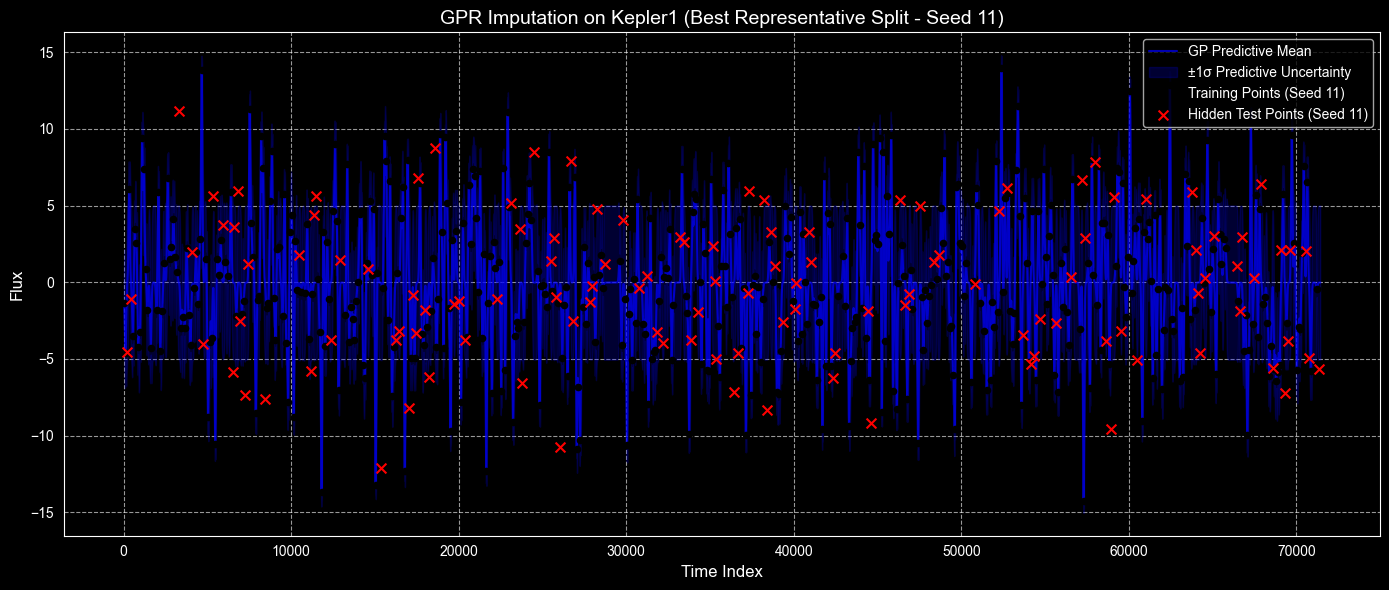

In [6]:
# Step 1: Identify the best performing seed for Kepler 1
best_k1_idx = np.argmin(gp_rmse_list)
best_k1_seed = seeds[best_k1_idx]

print(f"Generating visualization for Best Kepler 1 Seed: {best_k1_seed} (RMSE: {gp_rmse_list[best_k1_idx]:.4f})")

# Step 2: Recreate the train/test split for that specific best seed
t1_train_best, t1_test_best, y1_train_best, y1_test_best = train_test_split(
    t1_sub, y1_sub, test_size=0.2, random_state=best_k1_seed
)

X1_train_best = t1_train_best.reshape(-1, 1)

# Step 3: Retrain the GP model on the best split
gpr1_best = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=best_k1_seed)
gpr1_best.fit(X1_train_best, y1_train_best)

# Step 4: Predict over the FULL original time range to generate the smooth background band
X1_all = t1.reshape(-1, 1)
y1_pred_all_best, y1_std_all_best = gpr1_best.predict(X1_all, return_std=True)

# Step 5: Publication-style Plotting
plt.figure(figsize=(14, 6))

# Plot full predictive band for the winning model
plt.plot(t1, y1_pred_all_best, 'b-', label='GP Predictive Mean', linewidth=1.5, alpha=0.7)
plt.fill_between(t1, y1_pred_all_best - y1_std_all_best, y1_pred_all_best + y1_std_all_best,
                 color='blue', alpha=0.2, label='±1σ Predictive Uncertainty')

# Overlay test/train for this specific best split
plt.scatter(t1_train_best, y1_train_best, c='black', s=20, label=f'Training Points (Seed {best_k1_seed})', zorder=3)
plt.scatter(t1_test_best, y1_test_best, c='red', marker='x', s=50, label=f'Hidden Test Points (Seed {best_k1_seed})', zorder=4)

plt.xlabel("Time Index", fontsize=12)
plt.ylabel("Flux", fontsize=12)
plt.title(f"GPR Imputation on Kepler1 (Best Representative Split - Seed {best_k1_seed})", fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
# --- RANDOMIZED BLOCK MASKING EXPERIMENT ---
n_block_seeds = 20
block_size = int(len(t1_sub) * 0.2) # 20% continuous gap
max_start_idx = len(t1_sub) - block_size

gap_rmse_list, gap_mae_list, gap_r2_list, gap_1sigma_list, gap_2sigma_list = [], [], [], [], []

print("Running Randomized Block Masking Evaluation...")

for seed in range(n_block_seeds):
    rng = np.random.RandomState(seed)
    start_idx = rng.randint(0, max_start_idx)
    end_idx = start_idx + block_size

    # Create mask for the gap
    train_mask = np.ones(len(t1_sub), dtype=bool)
    train_mask[start_idx:end_idx] = False
    test_mask = ~train_mask

    t_train_gap, y_train_gap = t1_sub[train_mask], y1_sub[train_mask]
    t_test_gap, y_test_gap = t1_sub[test_mask], y1_sub[test_mask]

    # Fit & Predict
    gpr_gap = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr_gap.fit(t_train_gap.reshape(-1, 1), y_train_gap)
    y_pred_gap, y_std_gap = gpr_gap.predict(t_test_gap.reshape(-1, 1), return_std=True)

    # Evaluate
    gap_rmse_list.append(np.sqrt(mean_squared_error(y_test_gap, y_pred_gap)))
    gap_mae_list.append(mean_absolute_error(y_test_gap, y_pred_gap))
    gap_r2_list.append(r2_score(y_test_gap, y_pred_gap))
    gap_1sigma_list.append(np.mean((y_test_gap >= y_pred_gap - y_std_gap) & (y_test_gap <= y_pred_gap + y_std_gap)))
    gap_2sigma_list.append(np.mean((y_test_gap >= y_pred_gap - 2*y_std_gap) & (y_test_gap <= y_pred_gap + 2*y_std_gap)))

print("\n--- Block Masking (Continuous Gap) Aggregates ---")
print(f"Mean Gap RMSE: {np.mean(gap_rmse_list):.4f} ± {np.std(gap_rmse_list):.4f}")
print(f"Mean Gap MAE:  {np.mean(gap_mae_list):.4f} ± {np.std(gap_mae_list):.4f}")
print(f"Mean Gap R^2 score: {np.mean(gap_r2_list):.4f} ± {np.std(gap_r2_list):.4f}")
print(f"Mean 1σ Coverage: {np.mean(gap_1sigma_list)*100:.2f}%")
print(f"Mean 2σ Coverage: {np.mean(gap_2sigma_list)*100:.2f}%")

Running Randomized Block Masking Evaluation...

--- Block Masking (Continuous Gap) Aggregates ---
Mean Gap RMSE: 5.0891 ± 0.2717
Mean Gap MAE:  4.1182 ± 0.2467
Mean Gap R^2 score: -0.0079 ± 0.0088
Mean 1σ Coverage: 64.08%
Mean 2σ Coverage: 95.83%


### Modeling Structured Periodicity with `Kepler2.dat` using _Quasi-Periodic_ Kernel

The most common and most reliable kernel for stellar activity is the quasi-periodic kernel

> Mathematically, the `Quasi-Periodic Kernel` can be written as: <br>
$$
\gamma (t_i, t_j) = H_\mathrm{amp}^2  \exp{ \left \{-\frac{\sin^2{[\pi(t_i - t_j)/ P_\mathrm{rot}]}}{2 O_\mathrm{amp} ^2} - \frac{(t_i-t_j)^2}{2 P_\mathrm{dec}^2} \right \} }
$$

where, <br>
* $P_{\text{rot}}$ is the rotational period of the star
* $O_{\text{amp}}$ is the coherence scale
* $P_{\text{dec}}$ is the decay time scale of the active regions
* $H_{\text{amp}}$ is the amplitude of the kernel

In [8]:
from sklearn.gaussian_process.kernels import ExpSineSquared

# --- Kepler 2: Standard vs Quasi-Periodic Evaluation ---
# Step 1: Load and isolate valid data
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
t2 = np.arange(len(flux2))

mask2 = ~np.isnan(flux2)
t2_valid = t2[mask2]
y2_valid = flux2[mask2]

# Subsample due to memory limitations
subset2 = 50
t2_sub = t2_valid[::subset2]
y2_sub = y2_valid[::subset2]

To define `Quasi-Periodic Kernel`, we combine: <br>
* `ExpSineSquared` → to capture periodicity
* `RBF` → to capture evolution over time
* `WhiteKernel` → to capture white noise

In [11]:
from sklearn.gaussian_process.kernels import ConstantKernel, ExpSineSquared, RBF, WhiteKernel

n_k2_seeds = 20

rbf_rmse_list, rbf_mae_list = [], []
qp_rmse_list, qp_mae_list = [], []

rbf_kernel2 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)
qp_kernel2 = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * ExpSineSquared(
        length_scale=10.0,
        periodicity=150.0,
        length_scale_bounds=(1e-2, 1e4),
        periodicity_bounds=(10.0, 1e4)
    )
    * RBF(
        length_scale=200.0,
        length_scale_bounds=(1e-2, 1e5)
    )
    + WhiteKernel(
        noise_level=1.0,
        noise_level_bounds=(1e-6, 1e2)
    )
)

print(f"Evaluating kernels on Kepler 2 across {n_k2_seeds} seeds...")

for seed in range(n_k2_seeds):
    t2_train, t2_test, y2_train, y2_test = train_test_split(t2_sub, y2_sub, test_size=0.2, random_state=seed)
    X2_train, X2_test = t2_train.reshape(-1, 1), t2_test.reshape(-1, 1)

    # RBF Baseline
    gpr2_rbf = GaussianProcessRegressor(kernel=rbf_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_rbf.fit(X2_train, y2_train)
    y_pred_rbf = gpr2_rbf.predict(X2_test)

    rbf_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_rbf)))
    rbf_mae_list.append(mean_absolute_error(y2_test, y_pred_rbf))

    # Quasi-Periodic Target
    gpr2_qp = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_qp.fit(X2_train, y2_train)
    y_pred_qp = gpr2_qp.predict(X2_test)

    qp_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_qp)))
    qp_mae_list.append(mean_absolute_error(y2_test, y_pred_qp))

# --- Kepler 2 Summary Table ---
k2_benchmark_data = {
    "Kernel Method": ["RBF (Standard)", "Quasi-Periodic"],
    "RMSE Mean": [np.mean(rbf_rmse_list), np.mean(qp_rmse_list)],
    "RMSE Std": [np.std(rbf_rmse_list), np.std(qp_rmse_list)],
    "MAE Mean": [np.mean(rbf_mae_list), np.mean(qp_mae_list)],
    "MAE Std": [np.std(rbf_mae_list), np.std(qp_mae_list)]
}

k2_benchmark_df = pd.DataFrame(k2_benchmark_data)
print("\n--- Kepler 2 Kernel Robustness Comparison ---")
display.display(k2_benchmark_df.round(4))

Evaluating kernels on Kepler 2 across 20 seeds...


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1


--- Kepler 2 Kernel Robustness Comparison ---


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,Kernel Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std
0,RBF (Standard),36.5371,9.0953,16.7843,2.1005
1,Quasi-Periodic,36.5366,9.0955,16.7836,2.1005


### --- Visualization of the Best Quasi-Periodic Model Split ---

Generating visualization for Best QP Seed: 7 (RMSE: 22.6338)


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


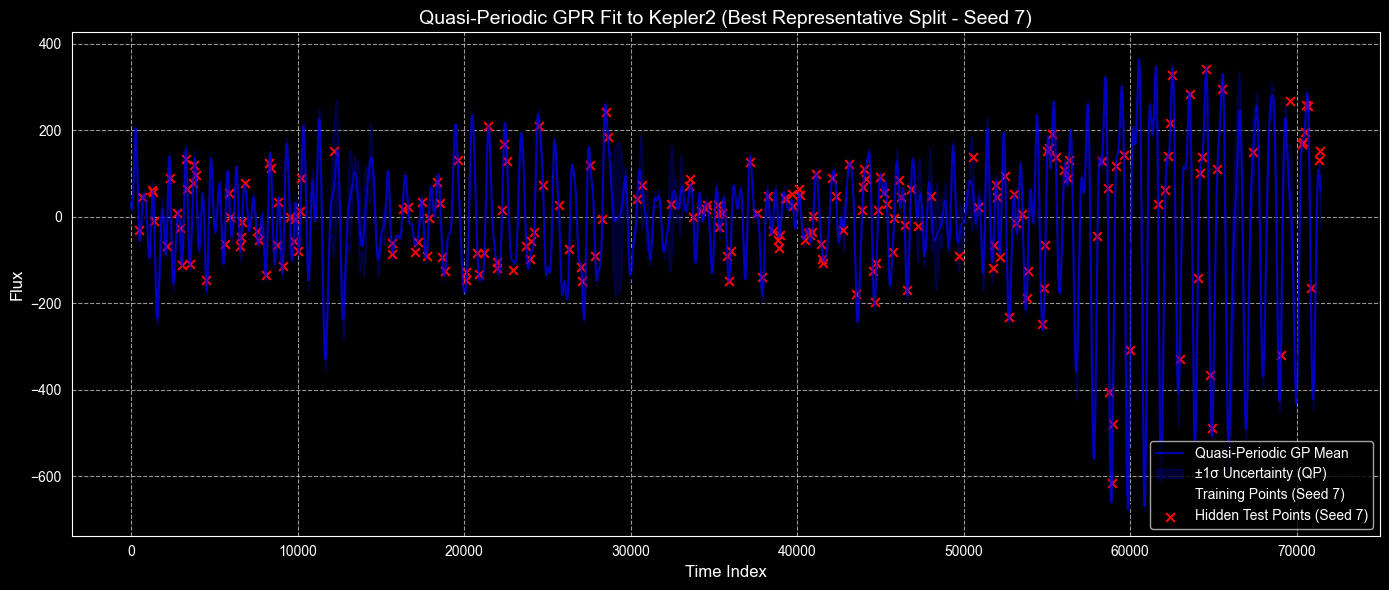

In [12]:
# Step 1: Identify the best performing seed for the QP kernel
best_qp_idx = np.argmin(qp_rmse_list)
best_qp_seed = best_qp_idx # Since our seeds were range(n_k2_seeds)

print(f"Generating visualization for Best QP Seed: {best_qp_seed} (RMSE: {qp_rmse_list[best_qp_idx]:.4f})")

# Step 2: Recreate the train/test split for that specific best seed
t2_train_best, t2_test_best, y2_train_best, y2_test_best = train_test_split(
    t2_sub, y2_sub, test_size=0.2, random_state=best_qp_seed
)

X2_train_best = t2_train_best.reshape(-1, 1)

# Step 3: Retrain the QP model on the best split
gpr2_qp_best = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=best_qp_seed)
gpr2_qp_best.fit(X2_train_best, y2_train_best)

# Step 4: Predict over the FULL time range to generate the smooth background band
X2_all = t2.reshape(-1, 1)
y2_pred_all_qp, y2_std_all_qp = gpr2_qp_best.predict(X2_all, return_std=True)

# Step 5: Publication-style Plotting
plt.figure(figsize=(14, 6))

# Plot full predictive band for the winning Quasi-Periodic model
plt.plot(t2, y2_pred_all_qp, 'b-', label='Quasi-Periodic GP Mean', alpha=0.7)
plt.fill_between(t2, y2_pred_all_qp - y2_std_all_qp, y2_pred_all_qp + y2_std_all_qp,
                 color='blue', alpha=0.2, label='±1σ Uncertainty (QP)')

# Overlay test/train for this specific best split
plt.scatter(t2_train_best, y2_train_best, c='black', s=10, label=f'Training Points (Seed {best_qp_seed})')
plt.scatter(t2_test_best, y2_test_best, c='red', marker='x', s=40, label=f'Hidden Test Points (Seed {best_qp_seed})')

plt.xlabel("Time Index", fontsize=12)
plt.ylabel("Flux", fontsize=12)
plt.title(f"Quasi-Periodic GPR Fit to Kepler2 (Best Representative Split - Seed {best_qp_seed})", fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()